# **Machine Learning - Lựa chọn mô hình học máy tối ưu**

**Mục tiêu:**
- Áp dụng nhiều mô hình machine learning khác nhau (ngoài LightGBM đã tối ưu trước đó) để dự báo doanh thu.
- So sánh hiệu quả các mô hình trên cùng bộ dữ liệu đã xử lý.
- Tất cả hàm train và tối ưu đều được xây dựng trong module `src/ml.py`.
- Đánh giá dựa trên các chỉ số: MAE, RMSE, MAPE, R2.

**Baseline LightGBM đã tối ưu trước đó: MAPE = 18,14%**

## Mục lục
1. [Thiết lập và chuẩn bị dữ liệu](#1)
2. [Huấn luyện và đánh giá các mô hình](#2)
3. [So sánh kết quả các mô hình](#3)
4. [Kết luận & Khuyến nghị](#4)

## 1. Thiết lập và chuẩn bị dữ liệu

In [2]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))
from src.get_data import get_data_processed
from src.models import run_all_models, run_single_model

In [4]:
df = get_data_processed("final_features.csv")
# df.drop(['is_pre_tet_rush', 'is_tet_holiday', 'is_double_day'], axis=1, inplace=True)
df.head()

Đã đọc thành công dữ liệu từ: D:\datathon\vimchanhxa-datathon\data\processed\final_features.csv


,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,days_since_start,month,day_of_month,...,is_promo,total_discount,sessions,unique_visitors,page_views,bounce_rate,avg_session_duration_sec,conversion_rate,average_order_value,items_per_order
0,2012-07-04,5123547.94,3982991.19,0,162.0,161.0,777.0,0,7.0,4.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31626.839136,4.796296
1,2012-07-05,2751773.45,2150580.23,0,97.0,97.0,428.0,1,7.0,5.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,28368.798454,4.412371
2,2012-07-06,3054029.42,2517632.84,0,93.0,93.0,441.0,2,7.0,6.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,32839.026022,4.741935
3,2012-07-07,2667930.94,2108246.62,0,73.0,73.0,364.0,3,7.0,7.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,36546.999178,4.986301
4,2012-07-08,2360851.90,1808622.79,0,88.0,87.0,394.0,4,7.0,8.0,...,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,26827.862500,4.477273


## 2. Huấn luyện và đánh giá các mô hình
Để tìm ra mô hình tốt nhất cho bài toán cũng như bộ dữ liệu features của chúng tôi, chúng tôi đã tổng hợp lại một vài mô hình phổ biến nhất với `random_seed = 42` và những thông số cơ bản cho các mô hình. Điều này giúp tôi đánh giá công bằng được mô hình nào tốt nhất hiện tại và sẽ được sử dụng để tối ưu. Dưới đây là danh sách các models của chúng tôi
- Linear (Baseline):
    - LinearRegression
- Tree:
    - DecisionTree
    - RandomForest
    - ExtraTrees
- Boosting (sklearn):
    - HistGradientBoosting
    - AdaBoost
- External Boosting
    - XGBoost
    - CatBoost
    - LightGBM

Tất cả models sẽ được đánh giá dựa trên 4 tiêu chí sau: `MAE`, `RMSE`, `MAPE` và `R-squared` 

In [6]:
target = 'revenue'
features = [col for col in df.columns if col not in ['date', 'order_count', 'cogs', 'is_test', 'unique_customers', 'total_quantity', target]]

In [7]:
evaluate_models = run_all_models(df, target_col=target, feature_cols=features)
evaluate_models

Done: LinearRegression
Done: DecisionTree
Done: RandomForest
Done: ExtraTrees
Done: HistGradientBoosting
Done: AdaBoost
Done: LightGBM
Done: XGBoost
Done: CatBoost


,Model,MAE,RMSE,MAPE,R-squared
0,CatBoost,185852.516797,2.548823e+05,6.665418,0.976812
1,LightGBM,198602.810350,2.862517e+05,6.828596,0.970753
2,HistGradientBoosting,210787.636541,3.038156e+05,7.362833,0.967054
3,XGBoost,235214.762264,3.507062e+05,7.861474,0.956099
4,ExtraTrees,352033.376562,5.149488e+05,11.458690,0.905351
5,RandomForest,419203.725123,6.404007e+05,12.905181,0.853617
6,LinearRegression,601325.971947,7.951242e+05,23.836219,0.774338
7,DecisionTree,657967.469315,9.797871e+05,20.634681,0.657350
8,AdaBoost,925809.913583,1.091880e+06,43.667002,0.574463


In [8]:
best_model = evaluate_models['Model'].iloc[0]
print("Model tốt nhất là:", best_model)

Model tốt nhất là: CatBoost


In [9]:
val_result, model, metrics = run_single_model(model_name=best_model, df=df, target_col=target, feature_cols=features)

print("Metrics:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value}")

Metrics:
MAE: 185852.51679651285
RMSE: 254882.339681446
MAPE: 6.6654182668399455
R-squared: 0.9768117902481568


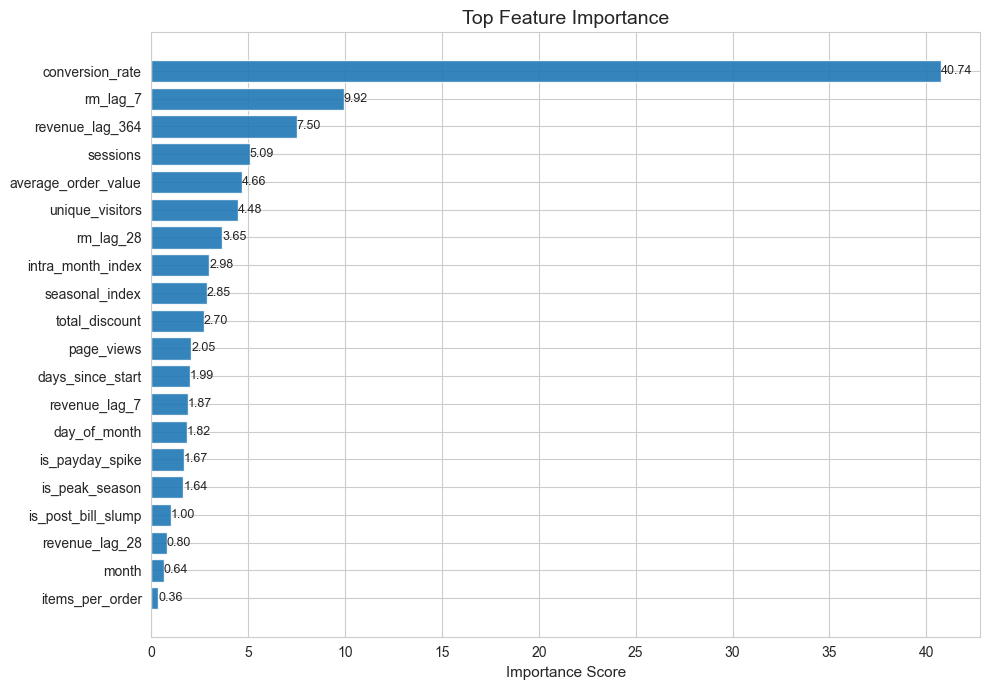

In [10]:
from src.visualization import *
plot_feature_importance(model, features)

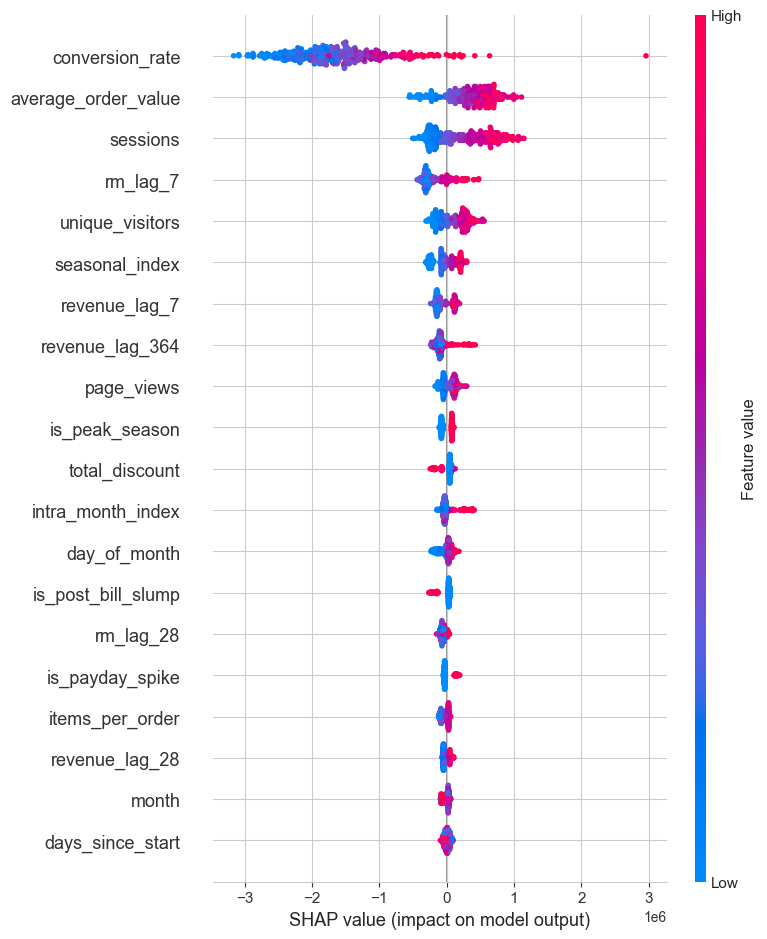

In [11]:
plot_shap_summary(model, val_result, features)

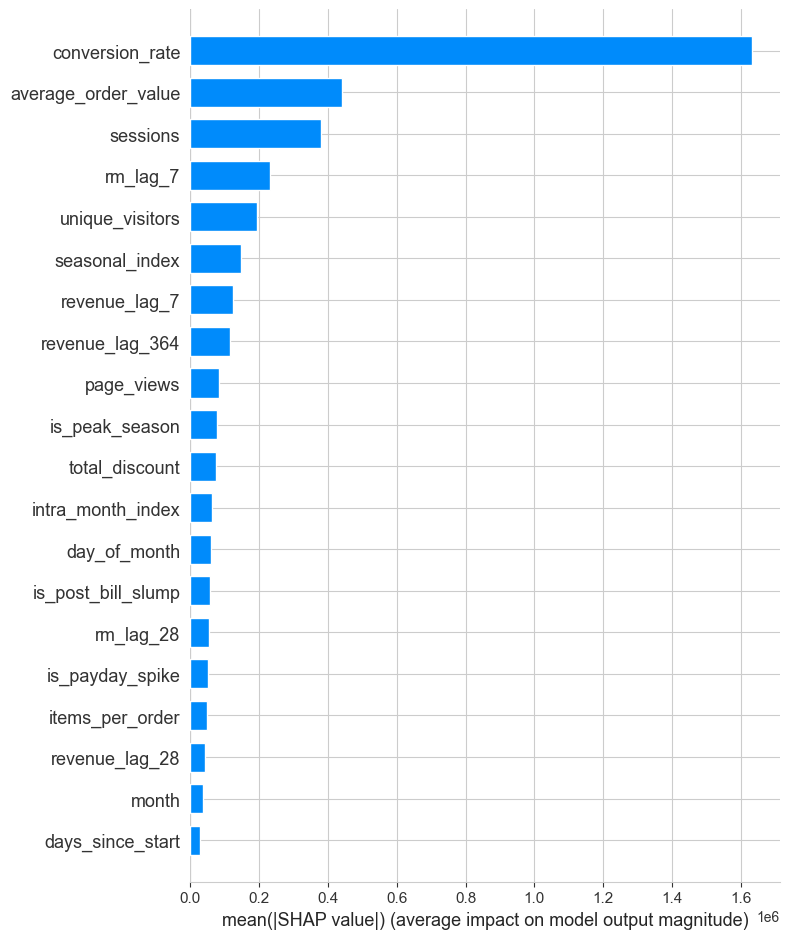

In [12]:
plot_shap_bar(model, val_result, features)

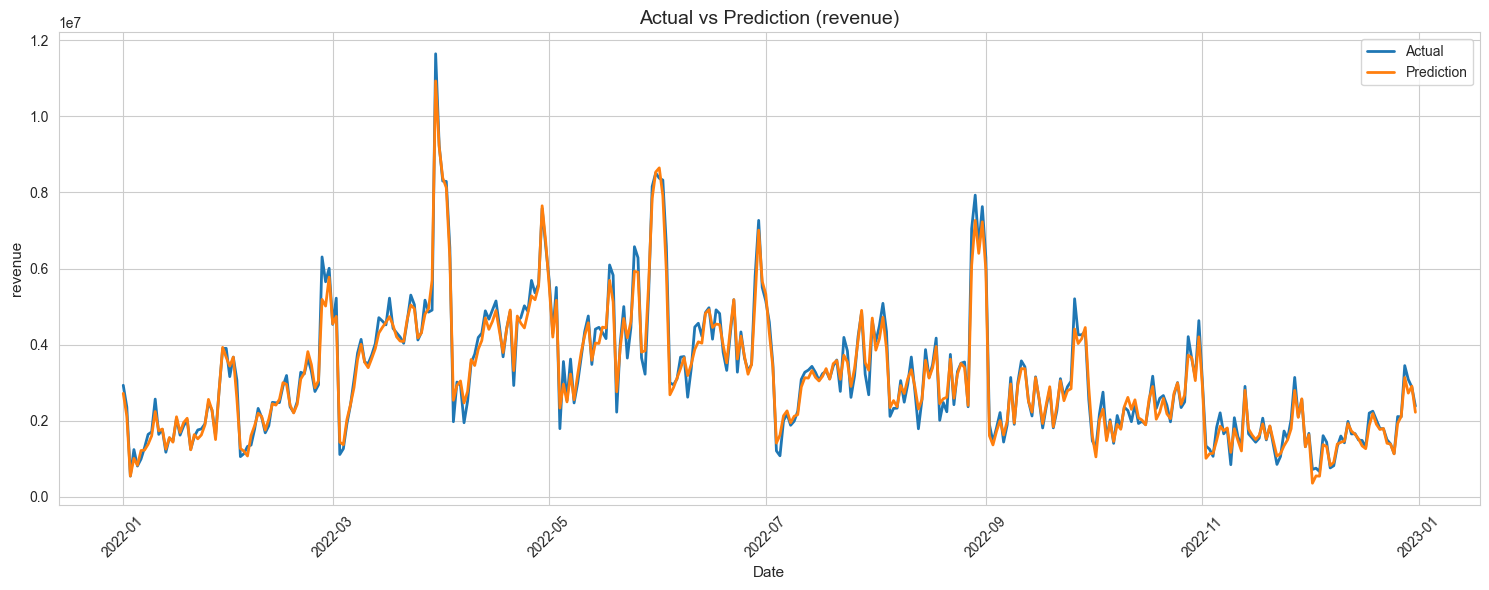

In [13]:
plot_prediction_vs_actual(val_result, target = target)

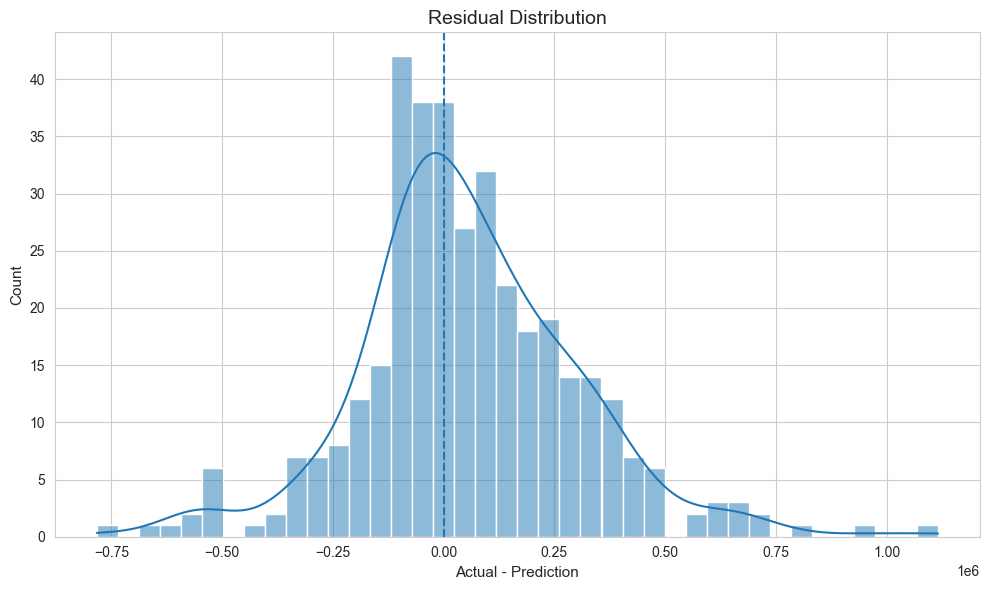

In [14]:
plot_residuals(val_result, target = target)

## 3. Tối ưu hóa tham số

In [15]:
from src.optimization import tune_optuna_walkforward
cb_params = tune_optuna_walkforward(model_name='CatBoost', df=df, target=target, features=features, n_trials=50)
xg_params = tune_optuna_walkforward(model_name='XGBoost', df=df, target=target, features=features, n_trials=50)
lg_params = tune_optuna_walkforward(model_name='LightGBM', df=df, target=target, features=features, n_trials=50)

[I 2026-05-01 20:00:34,194] A new study created in memory with name: no-name-7076cbcf-177b-4b3f-becd-b7b9f6fba335


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-01 20:04:10,245] Trial 0 finished with value: 369200.0280083339 and parameters: {'iterations': 987, 'depth': 10, 'learning_rate': 0.061239575926798365, 'l2_leaf_reg': 7.585243326167403, 'subsample': 0.7468055921327309}. Best is trial 0 with value: 369200.0280083339.
[I 2026-05-01 20:04:18,022] Trial 1 finished with value: 317656.1863131694 and parameters: {'iterations': 702, 'depth': 4, 'learning_rate': 0.07063233020424546, 'l2_leaf_reg': 7.612265129175297, 'subsample': 0.9124217733388136}. Best is trial 1 with value: 317656.1863131694.
[I 2026-05-01 20:06:33,529] Trial 2 finished with value: 387896.05145336944 and parameters: {'iterations': 526, 'depth': 10, 'learning_rate': 0.06827098485602953, 'l2_leaf_reg': 3.3357302174610375, 'subsample': 0.7545474901621302}. Best is trial 1 with value: 317656.1863131694.
[I 2026-05-01 20:06:51,156] Trial 3 finished with value: 298967.4892295972 and parameters: {'iterations': 738, 'depth': 6, 'learning_rate': 0.046732950214256656, 'l2_l

[I 2026-05-01 20:28:05,653] A new study created in memory with name: no-name-1d430fd3-025b-4f40-8913-186d8163052d


[I 2026-05-01 20:28:05,636] Trial 49 finished with value: 250814.0433662443 and parameters: {'iterations': 1672, 'depth': 4, 'learning_rate': 0.07022915024854759, 'l2_leaf_reg': 6.587609673627533, 'subsample': 0.855267519983123}. Best is trial 35 with value: 235641.43192927918.
MODEL: CatBoost
BEST SCORE: 235641.4319
BEST PARAMS:
{'iterations': 1419, 'depth': 5, 'learning_rate': 0.07505663672503672, 'l2_leaf_reg': 4.290158079595459, 'subsample': 0.9190923605277941}


...

[I 2026-05-01 20:28:51,994] Trial 0 finished with value: 505507.02493429824 and parameters: {'n_estimators': 987, 'max_depth': 10, 'learning_rate': 0.061239575926798365, 'subsample': 0.8795975452591109, 'colsample_bytree': 0.7468055921327309, 'min_child_weight': 2}. Best is trial 0 with value: 505507.02493429824.
[I 2026-05-01 20:29:03,540] Trial 1 finished with value: 433526.2531752058 and parameters: {'n_estimators': 575, 'max_depth': 9, 'learning_rate': 0.05207805082202462, 'subsample': 0.9124217733388136, 'colsample_bytree': 0.7061753482887407, 'min_child_weight': 10}. Best is trial 1 with value: 433526.2531752058.
[I 2026-05-01 20:29:13,595] Trial 2 finished with value: 313343.1681523728 and parameters: {'n_estimators': 1583, 'max_depth': 4, 'learning_rate': 0.022727747704497044, 'subsample': 0.7550213529560301, 'colsample_bytree': 0.7912726728878613, 'min_child_weight': 6}. Best is trial 2 with value: 313343.1681523728.
[I 2026-05-01 20:29:23,669] Trial 3 finished with value: 309

[I 2026-05-01 20:38:05,321] A new study created in memory with name: no-name-b0e89394-58ff-4da9-8a21-d6c69bf11fe8


[I 2026-05-01 20:38:05,303] Trial 49 finished with value: 441313.58902544447 and parameters: {'n_estimators': 1338, 'max_depth': 8, 'learning_rate': 0.07004480440843248, 'subsample': 0.7832153423563373, 'colsample_bytree': 0.7671292853555292, 'min_child_weight': 2}. Best is trial 43 with value: 268854.6517042356.
MODEL: XGBoost
BEST SCORE: 268854.6517
BEST PARAMS:
{'n_estimators': 1588, 'max_depth': 3, 'learning_rate': 0.06520063060063079, 'subsample': 0.7855000867099472, 'colsample_bytree': 0.9106653225503257, 'min_child_weight': 1}


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-01 20:38:11,557] Trial 0 finished with value: 416052.3693984929 and parameters: {'n_estimators': 987, 'num_leaves': 154, 'max_depth': 10, 'learning_rate': 0.05190609389379257, 'subsample': 0.7468055921327309, 'colsample_bytree': 0.7467983561008608}. Best is trial 0 with value: 416052.3693984929.
[I 2026-05-01 20:38:15,270] Trial 1 finished with value: 433610.6113842641 and parameters: {'n_estimators': 575, 'num_leaves': 142, 'max_depth': 9, 'learning_rate': 0.059565080445723194, 'subsample': 0.7061753482887407, 'colsample_bytree': 0.9909729556485982}. Best is trial 0 with value: 416052.3693984929.
[I 2026-05-01 20:38:19,143] Trial 2 finished with value: 325930.8496393101 and parameters: {'n_estimators': 1583, 'num_leaves': 49, 'max_depth': 4, 'learning_rate': 0.022838315689740367, 'subsample': 0.7912726728878613, 'colsample_bytree': 0.8574269294896714}. Best is trial 2 with value: 325930.8496393101.
[I 2026-05-01 20:38:30,649] Trial 3 finished with value: 388364.12814853055 

In [16]:
from src.models import compare_boosting_models

params = {
    'CatBoost': {'iterations': 1799, 'depth': 5, 'learning_rate': 0.07757365622458184, 'l2_leaf_reg': 2.404789242659949, 'subsample': 0.8783594713668782},
    'XGBoost': xg_params,
    'LightGBM': lg_params
}

compare_boosting_models(df, target_col=target, feature_cols=features, params_dict=params)

,Model,MAE,RMSE,MAPE,R-squared
0,CatBoost,129381.873281,181701.001522,4.893568,0.988216
1,XGBoost,159655.535041,217313.077688,5.828983,0.983144
2,LightGBM,171664.949250,227472.568726,6.228276,0.981531


In [17]:
val_result, model, metrics = run_single_model(model_name='CatBoost', df=df, target_col=target, feature_cols=features, params=params['CatBoost'])

print("Metrics:")
for metric_name, metric_value in metrics.items():
    print(f"{metric_name}: {metric_value}")

Metrics:
MAE: 129381.87328062106
RMSE: 181701.00152184468
MAPE: 4.893568044594583
R-squared: 0.9882157384707677


In [18]:
from src.models import run_rolling_forecast
forecast_result, model = run_rolling_forecast(model_name='CatBoost', df=df, target_col=target, feature_cols=features, params=best_params)

NameError: name 'best_params' is not defined

In [ ]:
target = 'cogs'
features = [col for col in df.columns if col not in ['date', 'order_count', 'is_test', 'unique_customers', 'total_quantity', target]]

forecast_result, model = run_rolling_forecast(model_name='CatBoost', df=forecast_result, target_col=target, feature_cols=features, params=best_params)
forecast_result.tail()

,date,revenue,cogs,is_test,order_count,unique_customers,total_quantity,day_of_week,day_of_month,day_of_year,...,year,is_weekend,days_since_start,seasonal_index,day_of_week_index,intra_month_index,is_payday,days_to_tet,is_promo,total_discount
4376,2024-06-27,4.712377e+06,3.952860e+06,1,NaN,NaN,NaN,3,27,179,...,2024,0,4376,1.463,1.023,1.175079,1,-138,0,0.0
4377,2024-06-28,4.541273e+06,3.748380e+06,1,NaN,NaN,NaN,4,28,180,...,2024,0,4377,1.463,0.938,1.385618,1,-139,0,0.0
4378,2024-06-29,5.905033e+06,4.949994e+06,1,NaN,NaN,NaN,5,29,181,...,2024,1,4378,1.463,0.918,1.551837,1,-140,0,0.0
4379,2024-06-30,5.364399e+06,4.476568e+06,1,NaN,NaN,NaN,6,30,182,...,2024,1,4379,1.463,0.971,1.694007,1,-141,0,0.0
4380,2024-07-01,4.626806e+06,3.774333e+06,1,NaN,NaN,NaN,0,1,183,...,2024,0,4380,1.115,1.026,1.480822,1,-142,0,0.0


In [ ]:
result = forecast_result[['date', 'revenue', 'cogs']][forecast_result['is_test'] == 1]
result 

,date,revenue,cogs
3833,2023-01-01,1.825315e+06,1.610802e+06
3834,2023-01-02,1.279668e+06,1.037144e+06
3835,2023-01-03,5.902023e+05,5.093774e+05
3836,2023-01-04,3.595216e+05,4.982269e+05
3837,2023-01-05,4.743112e+05,5.280318e+05
...,...,...,...
4376,2024-06-27,4.712377e+06,3.952860e+06
4377,2024-06-28,4.541273e+06,3.748380e+06
4378,2024-06-29,5.905033e+06,4.949994e+06
4379,2024-06-30,5.364399e+06,4.476568e+06


In [ ]:
from src.submission import create_submission
create_submission(result)

Submission file saved to ../data/processed/submission.csv


,Date,Revenue,COGS
3833,2023-01-01,1.825315e+06,1.610802e+06
3834,2023-01-02,1.279668e+06,1.037144e+06
3835,2023-01-03,5.902023e+05,5.093774e+05
3836,2023-01-04,3.595216e+05,4.982269e+05
3837,2023-01-05,4.743112e+05,5.280318e+05
...,...,...,...
4376,2024-06-27,4.712377e+06,3.952860e+06
4377,2024-06-28,4.541273e+06,3.748380e+06
4378,2024-06-29,5.905033e+06,4.949994e+06
4379,2024-06-30,5.364399e+06,4.476568e+06
